# 同条件组合信号与廉价生物信息

## tl;dr
不共享曲线拟合的原始孔残差相关为 **0.379 [0.312, 0.433]**。真实热点、靶点依赖及RNA模型确认数均为 **3.286**；零生物特征的静态先验混合也为 **3.286**。尚无可归因的生物信息动作增益。

## Context & Methods
2026-10-05研究目录；已曝光Jaaks数据；111条历史细胞、14条目标细胞。本笔记读取实际运行输出并重算选择，不训练或联网。恢复经过见RECOVERY_PLAN.md。

### Key Assumptions
- 同条件配对保留药物角色、浓度、密度、项目和时间；不同播种事件并非完全独立培养来源。
- 现有药物对向新细胞的评价不等于新药物对泛化。
- 原始孔端点与作者Synergy调用不同，95个复合干预只从原始孔检查排除。
- 固定P2以每次测量成本1计量，未计板布局/截止时间。
- 区间条件于历史、开发选择及固定菜单，不是方差上限。


In [1]:
from pathlib import Path
import json, math, sqlite3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
HERE = Path.cwd()
read_json = lambda name: json.loads((HERE/name).read_text())
repeat = read_json('results/summary.json')
matched = read_json('results/matched_orientation.json')['summary']
raw = read_json('raw_results/summary.json')['results']['raw_y']['summary']
biology = read_json('recovered_biology_results/summary.json')
verification = read_json('verification_recovery.json')
assert biology['training_lines']==111 and biology['target_lines']==14 and biology['overlap']==0
assert verification['status']=='PASS'
plt.rcParams.update({'font.size':11,'axes.spines.top':False,'axes.spines.right':False,'figure.dpi':130})
(HERE/'figures').mkdir(exist_ok=True)
print('111 history cells; 14 target cells; no training-target overlap.')


111 history cells; 14 target cells; no training-target overlap.


## Data
Jaaks公开原始孔与拟合数据；固定GDSC_footprints RNA快照；DepMap 24Q4 v1热点与CRISPR依赖。确切来源/版本/哈希见报告和输入收据。下面从随包数据库读取计数；行数不代表独立实验数。

In [2]:
catalog = read_json('evidence_catalog_manifest.json')
print(pd.DataFrame(catalog['counts'].items(),columns=['Table','Rows']).to_string(index=False))
with sqlite3.connect(f"file:{HERE/'feature_catalog.sqlite'}?mode=ro",uri=True) as db:
    print(pd.read_sql_query('SELECT COUNT(DISTINCT SIDM) AS cells,COUNT(DISTINCT gene) AS genes,COUNT(*) AS values_count FROM target_dependency',db).to_string(index=False))


               Table  Rows
     assay_condition 12247
         measurement 37348
      benchmark_pair  4519
candidate_prediction 54228
 raw_repeat_endpoint  4424
        model_recipe     1
 cells  genes  values_count
    94     61          5734


## Results
### 1. 重复一致性与取向改变
左图使用相同细胞/药物对，去掉独立历史先验；右图使用板内直接孔值。两图的端点与人群不同，不作差。误差线为细胞×药物对bootstrap 95%区间。

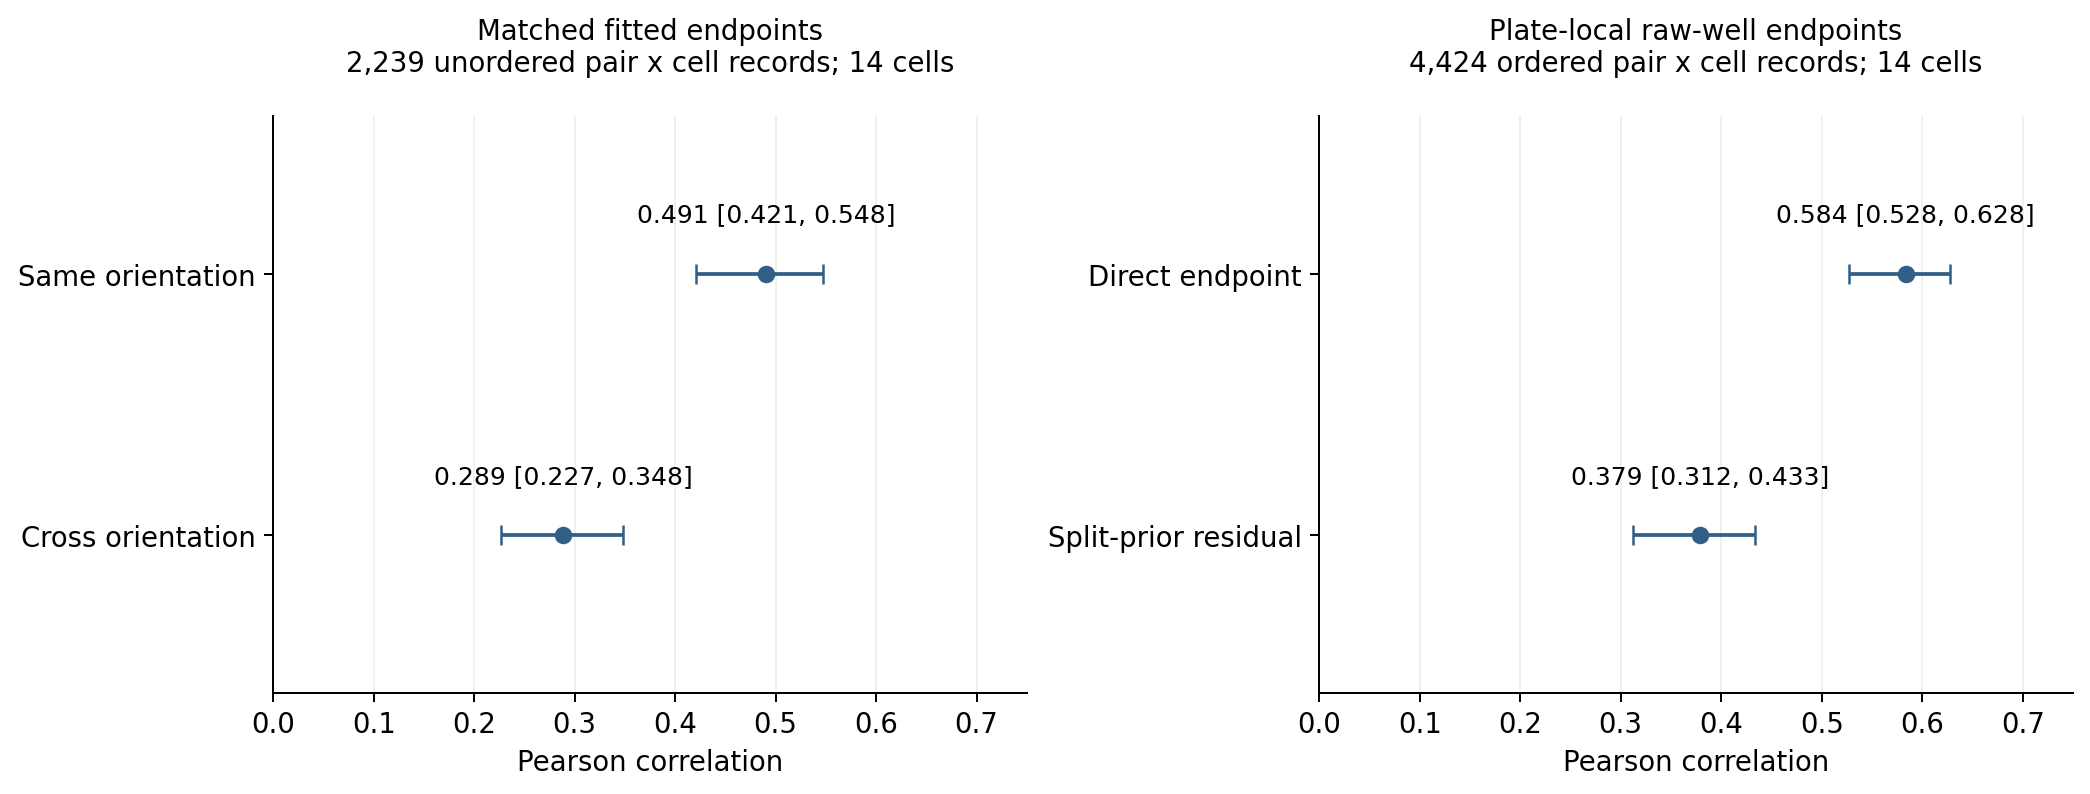

In [3]:
fig,axes=plt.subplots(1,2,figsize=(11.5,4.3),constrained_layout=True)
panels=[(axes[0],[('Same orientation',matched['split_same']),('Cross orientation',matched['split_cross'])],
         'Matched fitted endpoints','2,239 unordered pair x cell records; 14 cells'),
        (axes[1],[('Direct endpoint',raw['pearson']),('Split-prior residual',raw['residual_split'])],
         'Plate-local raw-well endpoints','4,424 ordered pair x cell records; 14 cells')]
for ax,items,title,subtitle in panels:
    for i,(label,item) in enumerate(items):
        point=item['mean'];lo,hi=item['line_pair_ci95']
        ax.errorbar(point,i,xerr=[[point-lo],[hi-point]],fmt='o',color='#315F88',capsize=4)
        ax.text(point,i-.20,f'{point:.3f} [{lo:.3f}, {hi:.3f}]',ha='center',fontsize=10)
    ax.set_yticks(range(len(items)),[label for label,_ in items]);ax.set_xlim(0,.75);ax.set_ylim(1.6,-.6)
    ax.set_xlabel('Pearson correlation');ax.grid(axis='x',alpha=.18)
    ax.set_title(title+'\n'+subtitle,fontsize=11,pad=18)
fig.savefig(HERE/'figures/repeat_signal.png',dpi=180,bbox_inches='tight');plt.close(fig)


一致性不完全来自共享曲线拟合。稳定培养、批次及系统误差仍可能贡献相关，不能把0.379解释成纯生物信号比例。

### 2. 确认收益与破坏性对照
每个回放使用相同菜单和预算上限。单位为每细胞×方向回放的平均；最后一行静态混合是结果后追加对照。

In [4]:
labels={'simple':'Strong simple baseline','hotspot':'Hotspot mutations','hotspot_shuffled':'Hotspot: shuffled cells',
        'dependency':'Target-gene dependency','dependency_shuffled':'Dependency: shuffled cells',
        'target_dependency':'Pair-target dependency','target_shuffled':'Shuffled target mapping','rna_binary':'RNA: binary objective',
        'prior_control':'Static prior mix (post hoc)'}
stats=biology['summary'];records=[]
for arm,label in labels.items():
    records.append({'Arm':label,'Confirmed':stats['P2_confirmed_'+arm]['mean'],
                    'Measurements':stats['P2_cost_'+arm]['mean'],'R2 positives':stats['R2_positive_'+arm]['mean']})
print(pd.DataFrame(records).round(3).to_string(index=False))


                        Arm  Confirmed  Measurements  R2 positives
     Strong simple baseline      3.250        27.179         5.536
          Hotspot mutations      3.286        27.250         5.536
    Hotspot: shuffled cells      3.250        27.179         5.571
     Target-gene dependency      3.286        27.321         5.500
 Dependency: shuffled cells      3.286        27.214         5.500
     Pair-target dependency      3.286        27.214         5.500
    Shuffled target mapping      3.286        27.214         5.536
      RNA: binary objective      3.286        27.214         5.571
Static prior mix (post hoc)      3.286        27.214         5.500


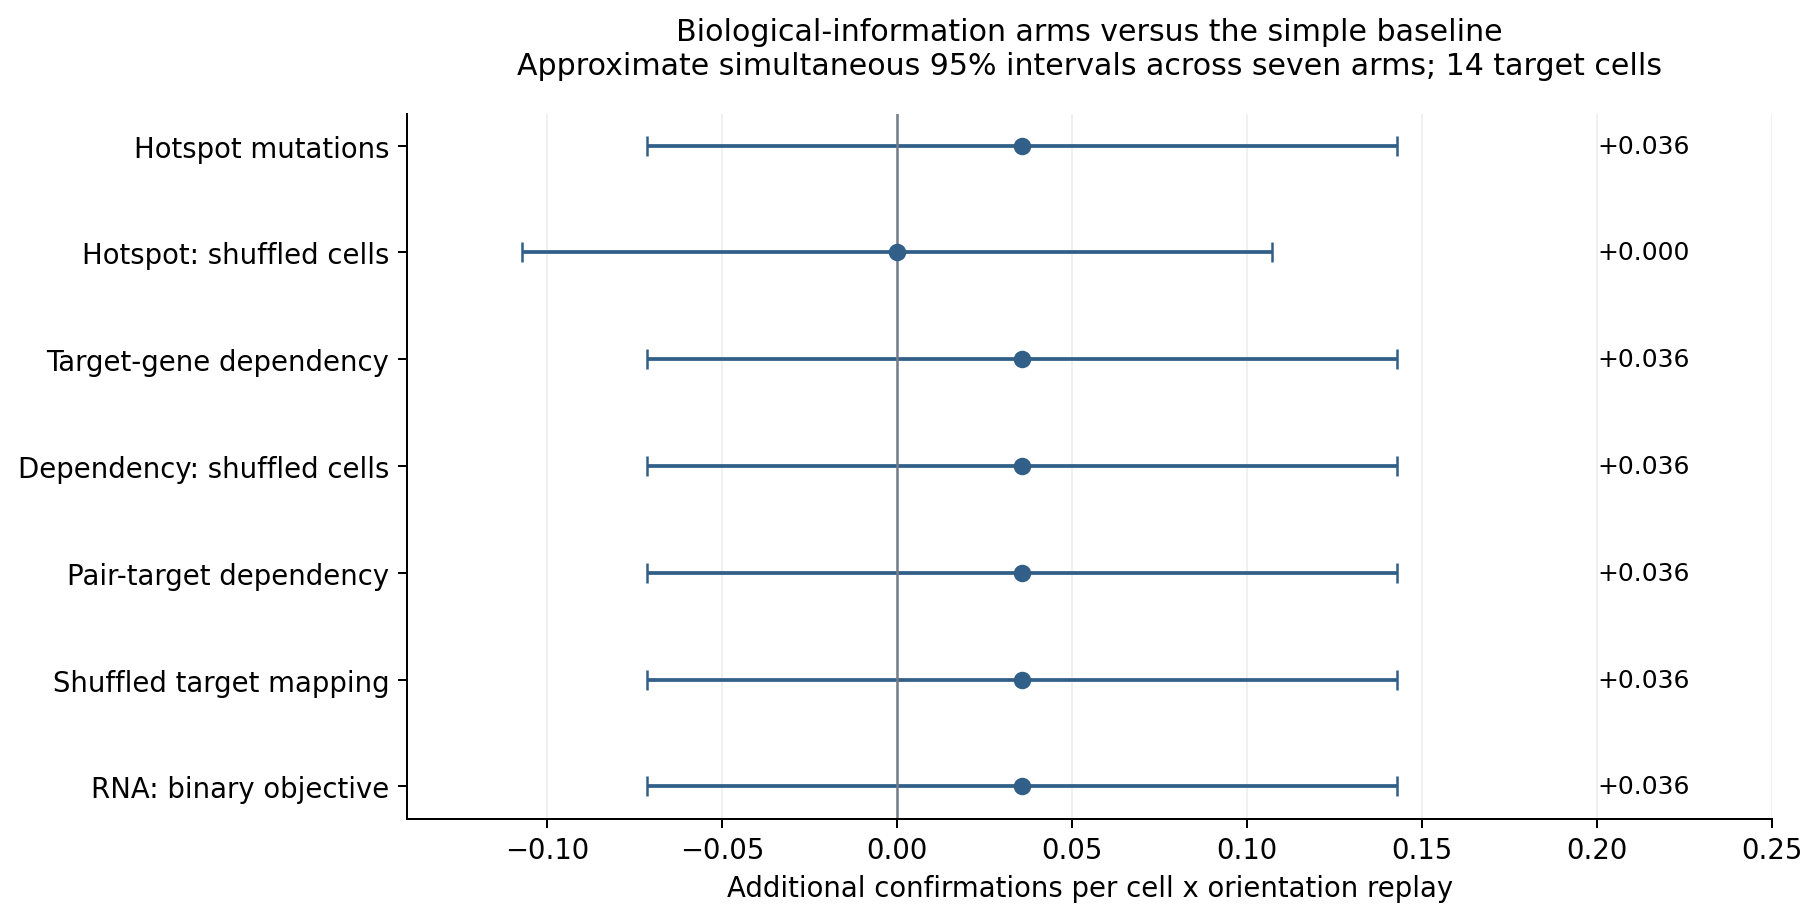

In [5]:
arms=[a for a in labels if a not in ['simple','prior_control']]
fig,ax=plt.subplots(figsize=(10,5),constrained_layout=True)
for i,arm in enumerate(arms):
    item=stats['P2_confirmed_'+arm+'_minus_simple'];point=item['mean'];lo,hi=item['simultaneous_seven_arm_ci95']
    ax.errorbar(point,i,xerr=[[point-lo],[hi-point]],fmt='o',color='#315F88',capsize=4)
    ax.text(.20,i,f'{point:+.3f}',va='center',fontsize=10)
ax.axvline(0,color='#737D89',lw=1);ax.set_yticks(range(len(arms)),[labels[a] for a in arms]);ax.invert_yaxis()
ax.set_xlim(-.14,.25);ax.grid(axis='x',alpha=.18)
ax.set_xlabel('Additional confirmations per cell x orientation replay')
ax.set_title('Biological-information arms versus the simple baseline\nApproximate simultaneous 95% intervals across seven arms; 14 target cells',fontsize=12,pad=16)
fig.savefig(HERE/'figures/action_gain.png',dpi=180,bbox_inches='tight');plt.close(fig)


+0.036表示28个回放中只多一次确认。静态先验混合得到同一确认集合；非零模型权重或开发分数变化不能证明生物信息有效。

In [6]:
predictions=pd.read_csv(HERE/'recovered_biology_results/predictions.csv.gz')
def confirmed_set(group,arm):
    budget=math.ceil(.2*len(group));screens=math.floor(.7*budget)
    ordered=group.sort_values([arm+'_score','pair'],ascending=[False,True]);candidate=ordered.iloc[:screens]
    verified=candidate[candidate.hit1].iloc[:budget-screens]
    return set(verified.loc[verified.hit2,'pair'])
differences={a:0 for a in ['hotspot','dependency','target_dependency','rna_binary']}
for _,group in predictions.groupby(['Tissue','SIDM','role']):
    control=confirmed_set(group,'prior_control')
    for arm in differences:differences[arm]+=confirmed_set(group,arm)!=control
assert not any(differences.values())
print('Replays with a different confirmed set from the static control:',differences)
baseline=stats['P2_confirmed_simple']['mean'];oracle=stats['P2_oracle']['mean']
print(f'Perfect-information ranking upper bound: {oracle:.3f}; baseline {baseline:.3f}; gap {oracle/baseline-1:.1%}')


Replays with a different confirmed set from the static control: {'hotspot': 0, 'dependency': 0, 'target_dependency': 0, 'rna_binary': 0}
Perfect-information ranking upper bound: 4.071; baseline 3.250; gap 25.3%


### 3. 额外重复：排序改善不等于同预算收益
以下使用共同R3子集。两次均值需要额外测量，尚未转化为等资源增益。

In [7]:
third=repeat['third_event']
print(pd.DataFrame([{'Ranking':a,'Spearman vs R3':third['rho_'+a]['mean'],
                     'R3 positives in top20%':third['R3_positive_count_'+a]['mean']}
                    for a in ['R1','R2','mean12']]).round(3).to_string(index=False))
print('Targeted synthetic tests:',len(verification['test_functions']))
print('Scalar policy reconstructions:',verification['reconstructed_policy_runs'])


Ranking  Spearman vs R3  R3 positives in top20%
     R1           0.613                   5.679
     R2           0.613                   5.643
 mean12           0.662                   5.750
Targeted synthetic tests: 14
Scalar policy reconstructions: 252


## Takeaways
- 同条件稳定残差值得进一步研究；跨取向低相关不是统一噪声上限。
- 当前热点、依赖和基础RNA未显示超出静态先验混合的确认价值。后者应进入下一轮强基线。
- 下一项信息应有剂量、时间和干预后状态含义，先资格审核与小模型对照；不先扩大参数。
- 当前数据库是研究数据层，生产双核心尚未迁移；未运行LLM，未开启Vis。

执行方式：标准Python顺序执行全部代码格，保存文本和实际生成的PNG；未使用Jupyter内核。它核查保存的输出，不替代外部验证或独立团队复核。